# Model comparison on the test set (t+1 target)
Load the saved XGBoost and logistic regression models for the **t+1** horizon (each with the threshold chosen during its own training notebook) and compare their performance on the held-out test set.

Run `train_xgboost_t1.ipynb` and `train_logreg_t1.ipynb` first, so the model artifacts exist.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import compare_models as cm
from compare_models import (
    compare_models,
    monthly_breakdown,
    plot_test_precision_recall_curves,
)
from explain_models import (
    compare_shap_importance,
    plot_shap_importance,
    plot_shap_summary,
    plot_shap_waterfall,
)

HORIZON = "t1"
cm.set_horizon(HORIZON)

MODEL_KEYS = cm.model_keys()
TARGET_COLUMN = cm.TARGET_COLUMN
MODEL_KEYS

Comparing t1 models with target 'target_t+1'


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


['xgboost_t1', 'log_reg_t1']

## Test-set metrics
Each model is evaluated at the threshold that was selected for it on its own validation split.

Precision and recall are computed **per month** and then averaged (`mean_monthly_*`), so months with more observations do not dominate the score. The pooled `overall_*` values are shown alongside for reference. `positive_rate` is the share of actual positives in the test set, i.e. the PR-AUC a random model would achieve.

In [2]:
comparison_df = compare_models(MODEL_KEYS)
comparison_df

,threshold,pr_auc,mean_monthly_precision,mean_monthly_recall,mean_monthly_f1,overall_precision,overall_recall,overall_f1,precision_at_k (k=90),recall_at_k (k=90),positive_rate
xgboost_t1,0.781688,0.155630,0.261198,0.041152,0.071102,0.259259,0.037634,0.065728,0.288889,0.069892,0.056846
log_reg_t1,0.828526,0.134022,0.206322,0.102408,0.136877,0.191176,0.104839,0.135417,0.188889,0.045699,0.056846


## Per-month breakdown
Precision and recall for each individual test month, showing how stable performance is over time.

In [3]:
for model_key in MODEL_KEYS:
    print(f"\n{model_key}")
    display(monthly_breakdown(model_key))


xgboost_t1


,yearmonth,precision,recall,n_positives,n_predicted_positive
0,2016-01,0.333333,0.055556,36,6
1,2016-02,0.250000,0.016667,60,4
2,2016-03,0.285714,0.035088,57,7
3,2016-04,0.428571,0.044118,68,7
4,2016-05,0.000000,0.000000,60,7
5,2016-06,0.300000,0.055556,54,10
6,2016-07,0.230769,0.081081,37,13



log_reg_t1


,yearmonth,precision,recall,n_positives,n_predicted_positive
0,2016-01,0.142857,0.083333,36,21
1,2016-02,0.150000,0.050000,60,20
2,2016-03,0.470588,0.140351,57,17
3,2016-04,0.235294,0.117647,68,34
4,2016-05,0.153846,0.133333,60,52
5,2016-06,0.166667,0.111111,54,36
6,2016-07,0.125000,0.081081,37,24


## Precision-recall curves
Threshold-independent view of how well each model ranks clients by credit application risk.

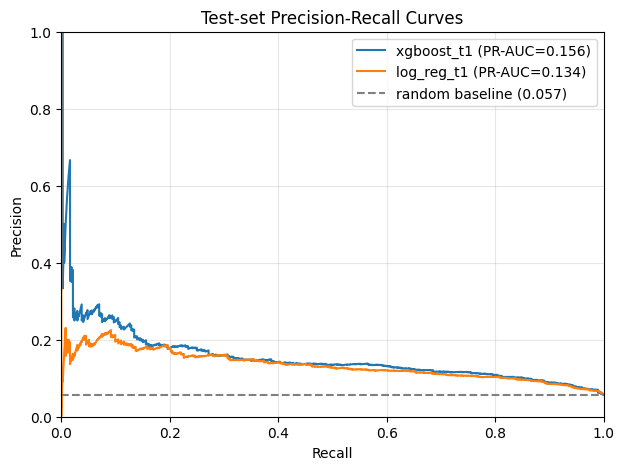

In [4]:
plot_test_precision_recall_curves(MODEL_KEYS)

## Lift over the random baseline

In [5]:
lift_df = comparison_df[["pr_auc", "positive_rate"]].copy()
lift_df["pr_auc_lift"] = lift_df["pr_auc"] / lift_df["positive_rate"]
lift_df

,pr_auc,positive_rate,pr_auc_lift
xgboost_t1,0.155630,0.056846,2.737749
log_reg_t1,0.134022,0.056846,2.357629


# Explainability (SHAP)
SHAP values decompose each prediction into per-feature contributions, so they show *which* features drive the model and in *which direction*. Computed on a sample of the test set.

## Feature importance
Mean absolute SHAP value per feature: how much each feature moves predictions on average.

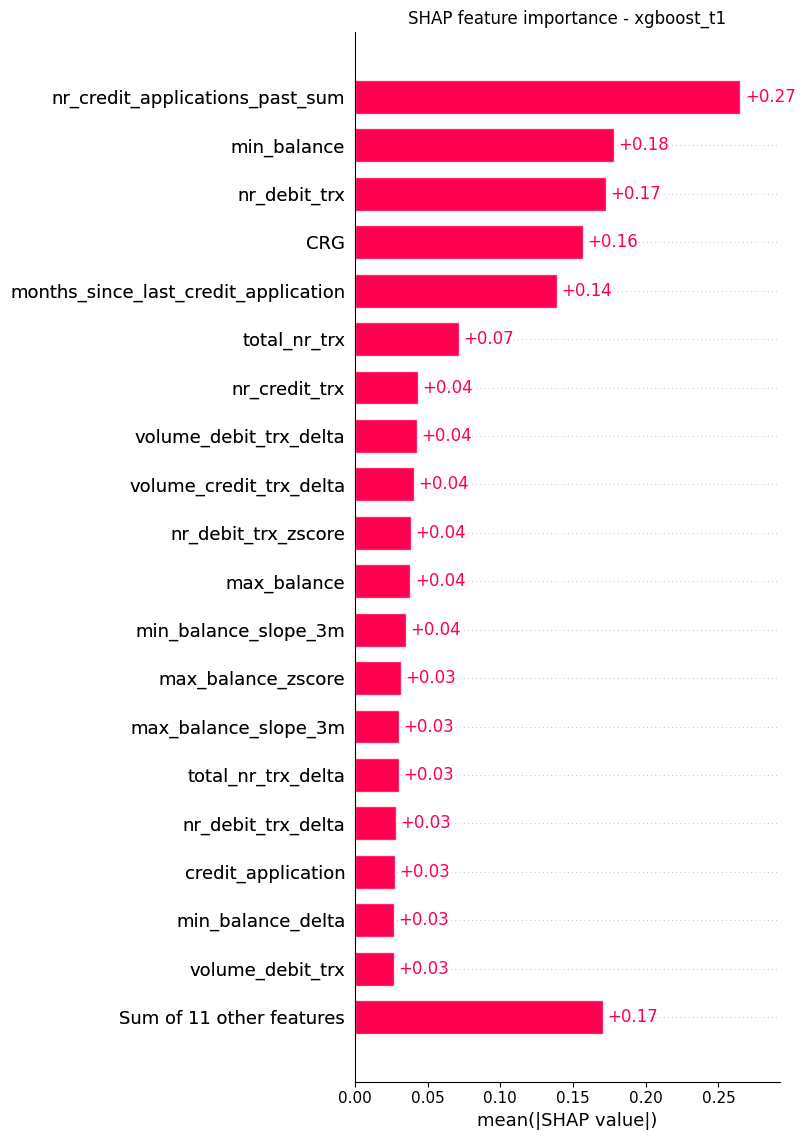

,feature,mean_abs_shap
0,nr_credit_applications_past_sum,0.265154
1,min_balance,0.177930
2,nr_debit_trx,0.172516
3,CRG,0.156967
4,months_since_last_credit_application,0.139095
5,total_nr_trx,0.071476
6,nr_credit_trx,0.043240
7,volume_debit_trx_delta,0.042481
8,volume_credit_trx_delta,0.040634
9,nr_debit_trx_zscore,0.038663


In [6]:
xgb_importance = plot_shap_importance(MODEL_KEYS[0])
xgb_importance.head(20)

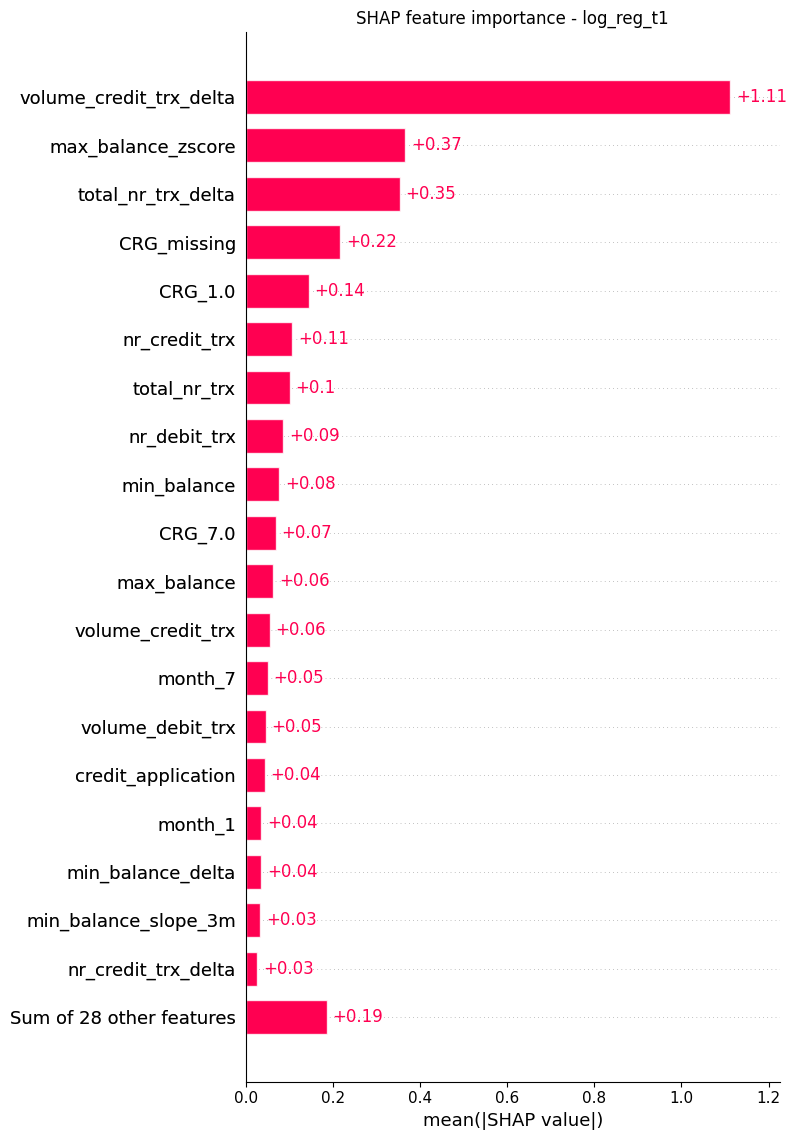

,feature,mean_abs_shap
0,volume_credit_trx_delta,1.112349
1,max_balance_zscore,0.366515
2,total_nr_trx_delta,0.354388
3,CRG_missing,0.217678
4,CRG_1.0,0.144904
5,nr_credit_trx,0.107014
6,total_nr_trx,0.101988
7,nr_debit_trx,0.086102
8,min_balance,0.077438
9,CRG_7.0,0.068868


In [7]:
logreg_importance = plot_shap_importance(MODEL_KEYS[1])
logreg_importance.head(20)

## Direction of effect
Beeswarm plot: each dot is one observation. Colour shows the feature value, position shows its SHAP contribution, so you can see whether high values push predictions up or down.

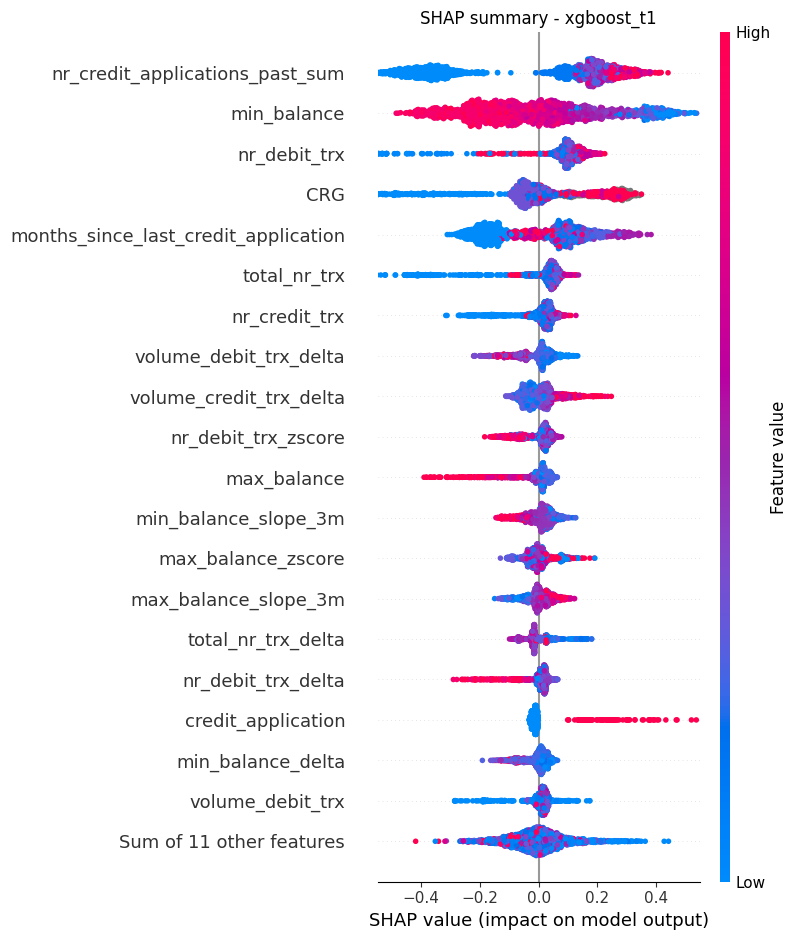

In [8]:
plot_shap_summary(MODEL_KEYS[0]);

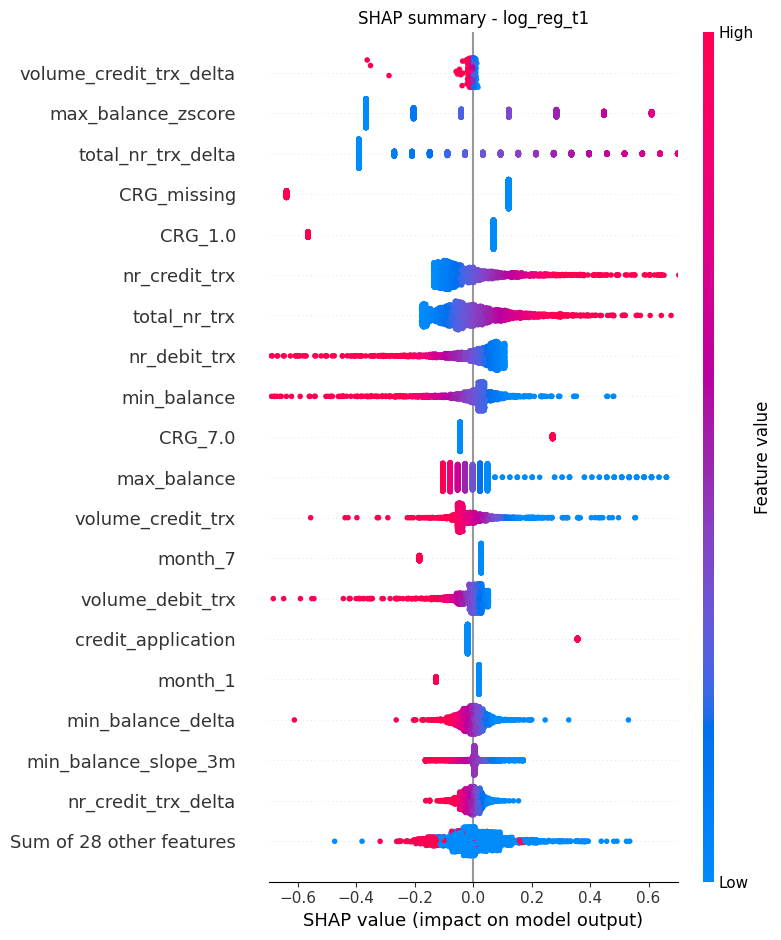

In [9]:
plot_shap_summary(MODEL_KEYS[1]);

## Do both models rely on the same features?
If the two model families agree on the important features, that is evidence the signal is real rather than an artifact of one model type.

In [10]:
compare_shap_importance(MODEL_KEYS)

,xgboost_t1,log_reg_t1,mean_rank
CRG,0.156967,NaN,4.0
CRG_missing,NaN,0.217678,4.0
CRG_1.0,NaN,0.144904,5.0
volume_credit_trx_delta,0.040634,1.112349,5.0
nr_debit_trx,0.172516,0.086102,5.5
min_balance,0.177930,0.077438,5.5
total_nr_trx,0.071476,0.101988,6.5
nr_credit_trx,0.043240,0.107014,6.5
max_balance_zscore,0.031543,0.366515,7.5
total_nr_trx_delta,0.030046,0.354388,9.0


## Explaining a single prediction
Waterfall plot showing how each feature pushed one specific client-month away from the model's base rate.

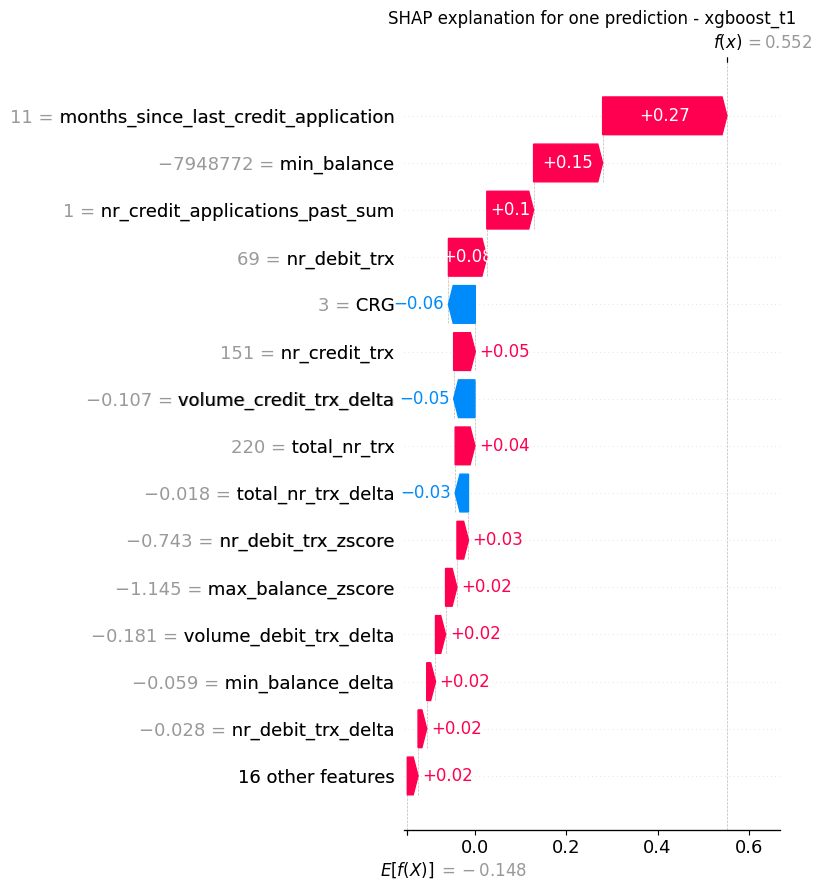

In [11]:
plot_shap_waterfall(MODEL_KEYS[0], observation_index=0)